In [1]:
import random
import matplotlib.pyplot as plt
from utils.serialize import read_jsonl, kg_from_dict

/people/boufouss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Display random graphs SNLI

In [2]:
PATH = "out/anli_train_r1/graphs.jsonl" #"out/snli_test/graphs.jsonl"
LABELS = {0: "entailment", 1: "neutral", 2: "contradiction"}

In [3]:
rows = list(read_jsonl(PATH))
print(len(rows), "exemples")

16946 exemples


16946 exemples
label : entailment


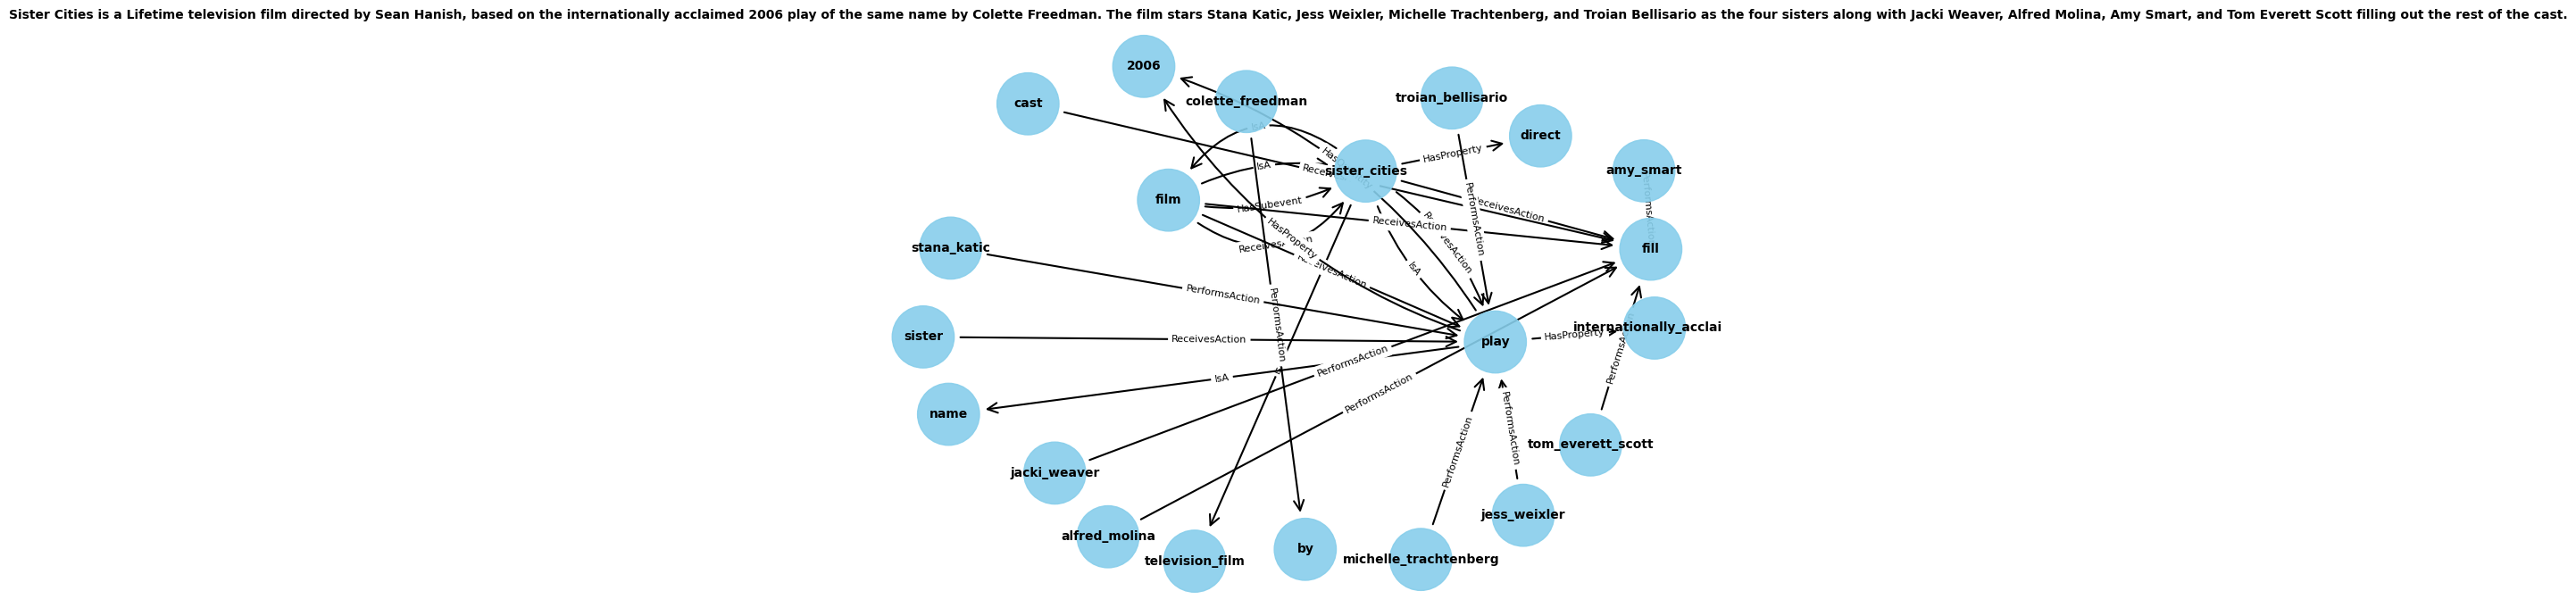

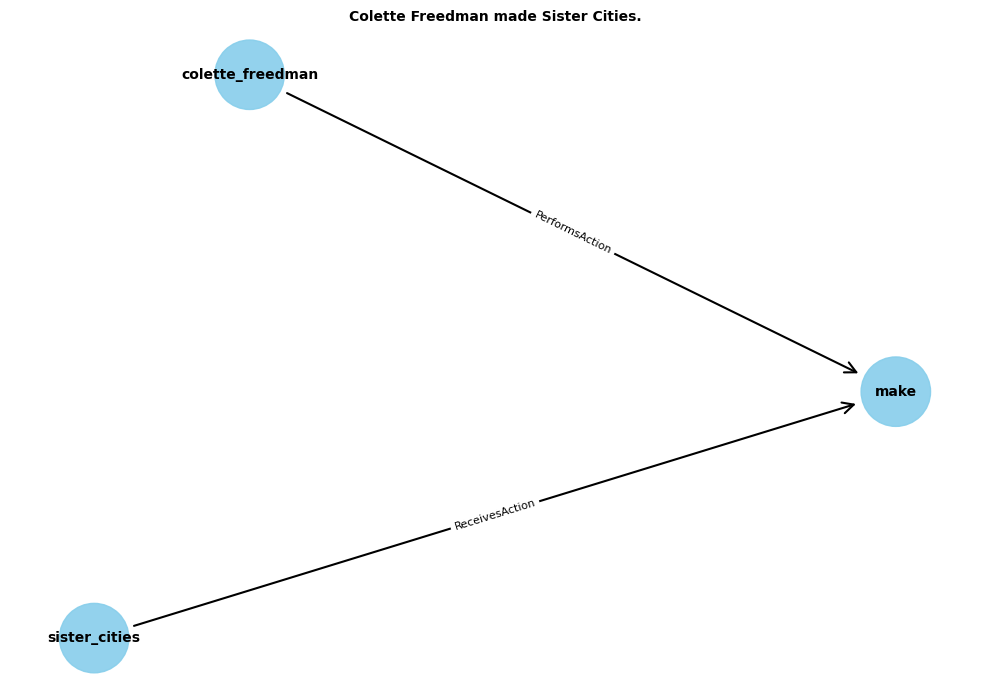

intersection : set()
label : contradiction


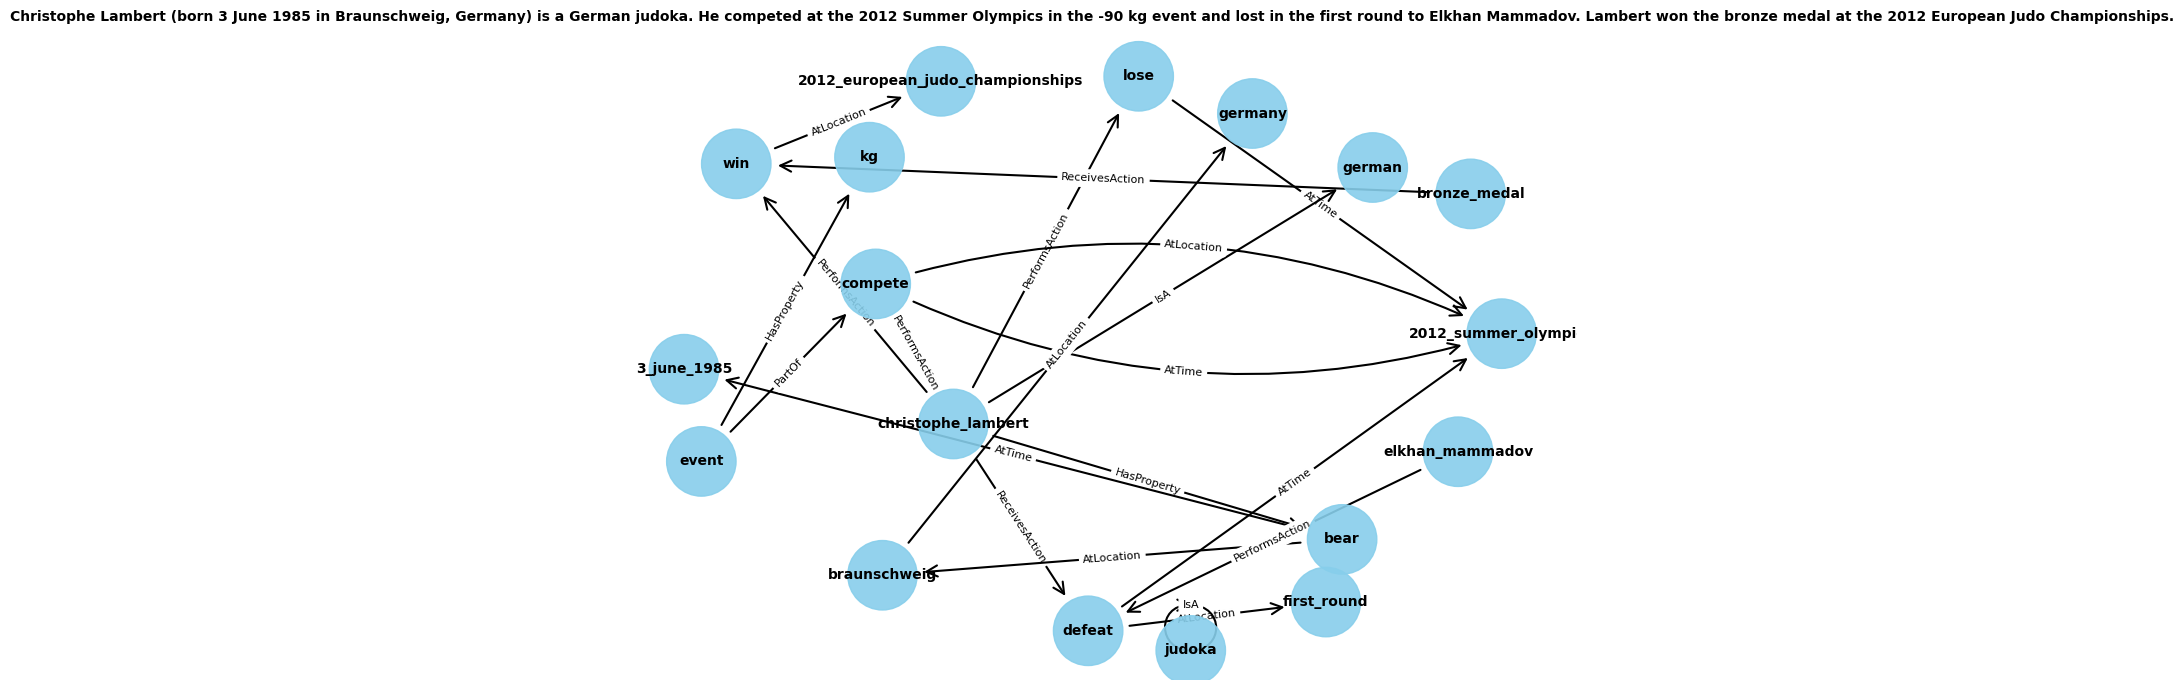

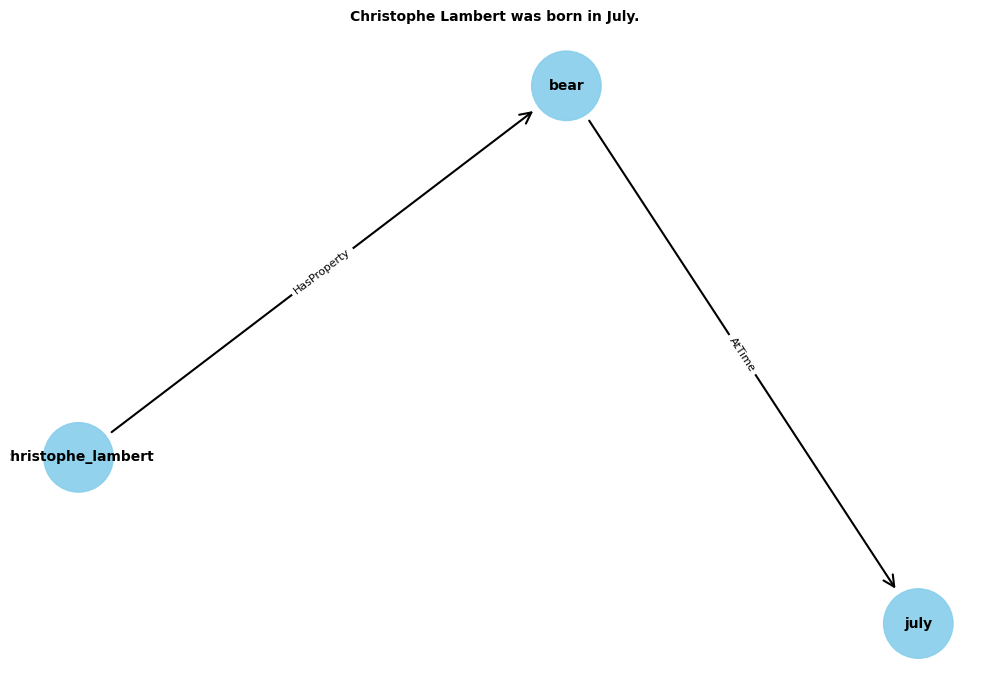

intersection : {('christophe_lambert', 'HasProperty', 'bear')}
label : neutral


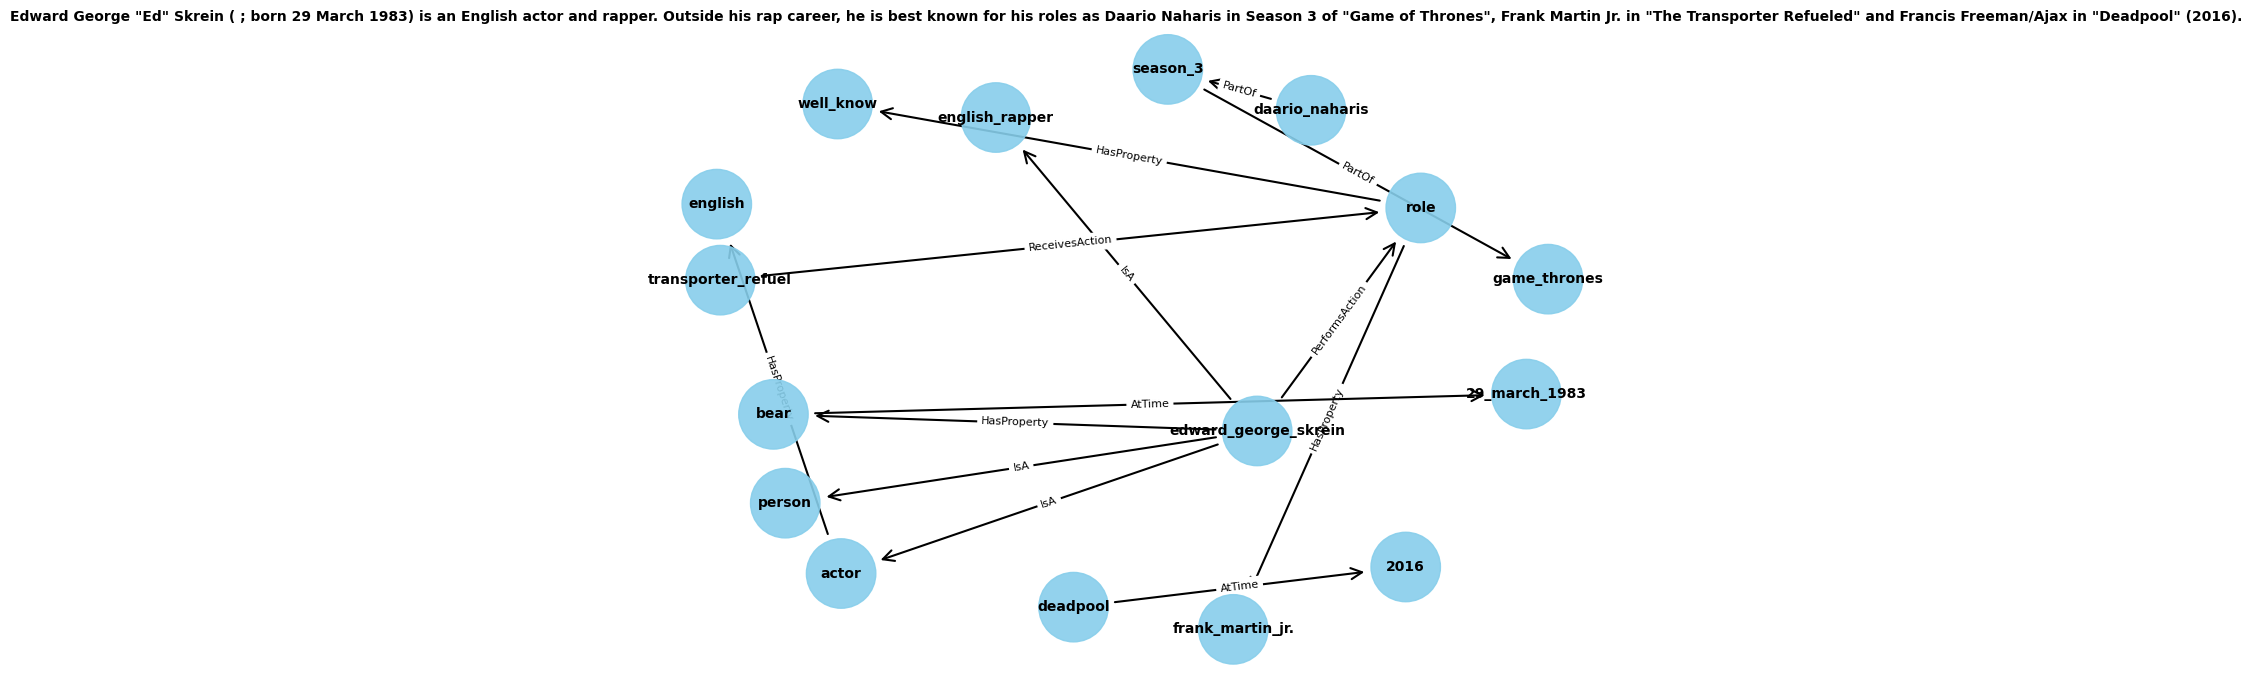

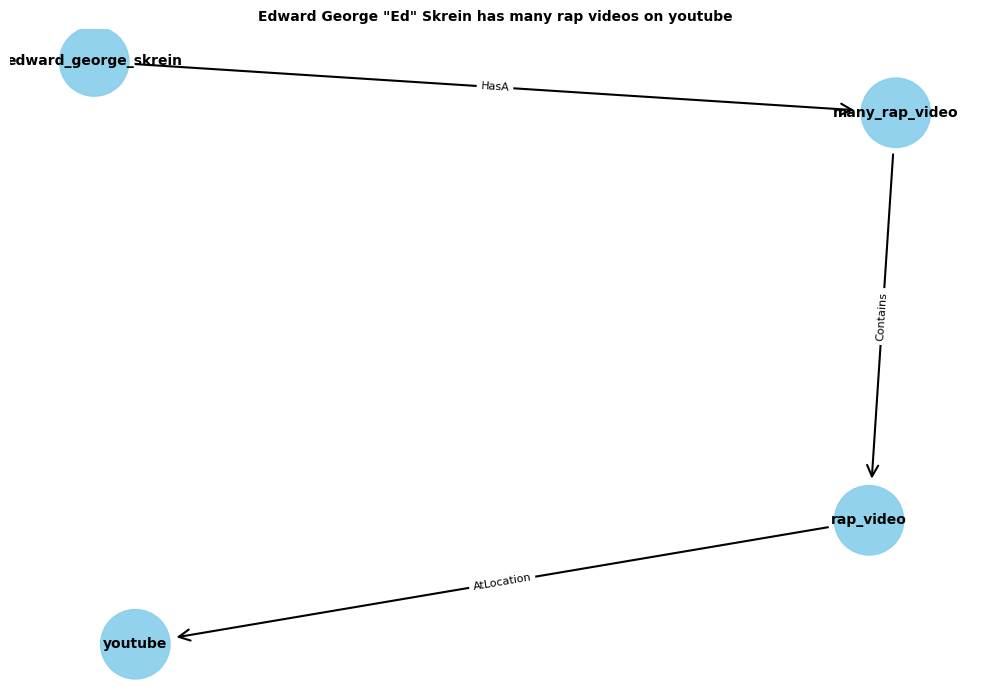

intersection : set()


In [ ]:
random.seed(42)
for row in random.sample(rows, 3):
    print("=" * 70)
    print("label :", LABELS.get(row["label"], row["label"]))

    P = kg_from_dict({"text": row["premise"],    "triples": row["premise_triples"]})
    H = kg_from_dict({"text": row["hypothesis"], "triples": row["hypothesis_triples"]})

    P.display()
    H.display()
    plt.show()
    print(f"intersection : {P.get_rel() & H.get_rel()}")

# Test augmentation

In [4]:
import pandas as pd
data = pd.read_csv('data/concept_net_en.csv')
data = data[['head_word', 'relation', 'tail_word', 'weight']]

In [5]:
from sentence_transformers import CrossEncoder
import numpy as np
CROSS_NAME = 'cross-encoder/stsb-roberta-base'
cross = CrossEncoder(CROSS_NAME, device="cuda:1")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [5]:
fwd = {w: g for w, g in data.groupby('head_word', sort=False)}
bwd = {w: g for w, g in data.groupby('tail_word', sort=False)}
empty = data.iloc[0:0]

In [22]:
def max_scores(links, sentences):
    links = list(links); sentences = list(sentences)
    if not links or not sentences:
        return np.zeros(len(links)), [None] * len(links)
    pairs = [(l, s) for l in links for s in sentences]
    sc = np.asarray(cross.predict(pairs), dtype=float).reshape(len(links), len(sentences))
    j = sc.argmax(axis=1)
    return sc[np.arange(len(links)), j], [sentences[k] for k in j]

import json
with open('data/relations.json', encoding='utf-8') as file:
    relations_raw = json.load(file)
    sentence_to_relation  = {item["sentence"] : item["relation"] for item in relations_raw["definitions"]}
    relation_to_sentence  = {item["relation"] : item["sentence"] for item in relations_raw["definitions"]}

def triples_to_sentences(triples):
    return [f"{h.replace('_', ' ')} {relation_to_sentence[r]} {t.replace('_', ' ')}" for (h, r, t, *_) in triples]

In [76]:
def get_rel_nodes(nodes, rel=None, forward = True):
    index = fwd if forward else bwd
    parts = [index[n] for n in set(nodes) if n in index]
    result = pd.concat(parts) if parts else empty

    if rel is not None:
        result = result[result['relation'].isin(rel)]

    return result

def score_path(scores, alpha = 0.5):
    return alpha*np.mean(scores)+(1-alpha)*np.max(scores)

def join_paths(hop, threshold):
    edge_cols = ['id_path', 'head', 'rel', 'tail', 'score_link', 'info_scored']
    path_cols = ['id_path', 'score_path']
    if not hop or hop[0].empty:
        return pd.DataFrame(columns=edge_cols), pd.DataFrame(columns=path_cols)

    def edges_of(df): 
        return list(df[['head_word', 'relation', 'tail_word', 'score', 'info_scored']]
                    .itertuples(index=False, name=None))

    frontier = [([e], e[2], {e[0], e[2]}) for e in edges_of(hop[0])]
    completed = []

    for k in range(1, len(hop)):
        by_head = {}
        for e in edges_of(hop[k]):
            by_head.setdefault(e[0], []).append(e)

        new_frontier = []
        for path, node, visited in frontier:
            if path[-1][3] == 1.0:                 
                completed.append(path); continue
            exts = [e for e in by_head.get(node, []) if e[2] not in visited]  
            if not exts:
                completed.append(path)             
            else:
                for e in exts:
                    new_frontier.append((path + [e], e[2], visited | {e[2]}))
        frontier = new_frontier
    completed.extend(p for p, _, _ in frontier) 

    scored = [(score_path([e[3] for e in path]), path) for path in completed]
    scored = [sp for sp in scored if sp[0] >= threshold]
    scored.sort(key=lambda x: x[0], reverse=True)

    edge_rows, path_rows = [], []
    for pid, (ps, path) in enumerate(scored):
        path_rows.append((pid, ps))
        for (h, r, t, sc, info) in path:
            edge_rows.append((pid, h, r, t, sc, info))

    return (pd.DataFrame(edge_rows, columns=edge_cols),
            pd.DataFrame(path_rows, columns=path_cols))



def related_data(source, target, dist = 1, threshold_link = 0.3, threshold_path= 0.5, forward = True):
    # Garder le seuil pour les chemins, mais faire un top_k (proportionnel à unresolved) pour garder les liens ?s
    ## TODO ?? : Avoir un poid different en fonction de la rel ? par exemple 'IsA' est presque obligatoire et systematique, 
    # elle permet de faire un premier pont, ensuite on prune les chemins 'IsA' qui n'ont rien de pertinent (score) qui partent d'eux

    cols = ['head_word', 'relation', 'tail_word', 'score', 'info_scored']

    unresolved = triples_to_sentences(target.get_rel() - source.get_rel()) ## Soustraire 'e' & 'rel' si P(x, rel, e) et H(y, rel, e) ??
    if not unresolved:
        return pd.DataFrame(columns=cols)

    start_entities = source.get_entities() - target.get_entities() #set([t[i] for t in (H.get_rel() - P.get_rel()) for i in (0,2)])
    target_entities = target.get_entities() - source.get_entities()

    next_col = 'tail_word' if forward else 'head_word'
    prev_col = 'head_word' if forward else 'tail_word'

    hops = []
    for _ in range(dist):
        if not start_entities :
            break

        df = get_rel_nodes(start_entities, forward= forward).copy()
        if df.empty :
            break

        match_mask = df[next_col].isin(target_entities)
        df['score'] = 0.0
        df['info_scored'] = None

        df.loc[match_mask, 'score'] = 1.
        df.loc[match_mask, 'info_scored'] = df.loc[match_mask, next_col]


        rest = df.loc[~match_mask]
        if len(rest):
            sents = triples_to_sentences([(h, r, t) for h, r, t in rest[['head_word', 'relation', 'tail_word']].itertuples(index=False, name=None)])
            scores, best = max_scores(sents, unresolved)
            df.loc[~match_mask, 'score'] = scores
            df.loc[~match_mask, 'info_scored'] = np.array(best, dtype=object)

        df = df[df['score'] >= threshold_link]
        if df.empty:
            break
        hops.append(df)
        
        start_entities = set(df[next_col]) - target_entities

    if not hops:
        return pd.DataFrame(columns=cols)
    
    return join_paths(hops, threshold= threshold_path)

In [10]:
# TODO : supp les doublons de conceptnet & les boucles

In [ ]:
## random.sample(rows, 1)[0]
#  rows[8928] bird-swan snli-test (ou dev)
# 6924
row = random.sample(rows, 1)[0]
P = kg_from_dict({"text": row["premise"],    "triples": row["premise_triples"]})
H = kg_from_dict({"text": row["hypothesis"], "triples": row["hypothesis_triples"]})

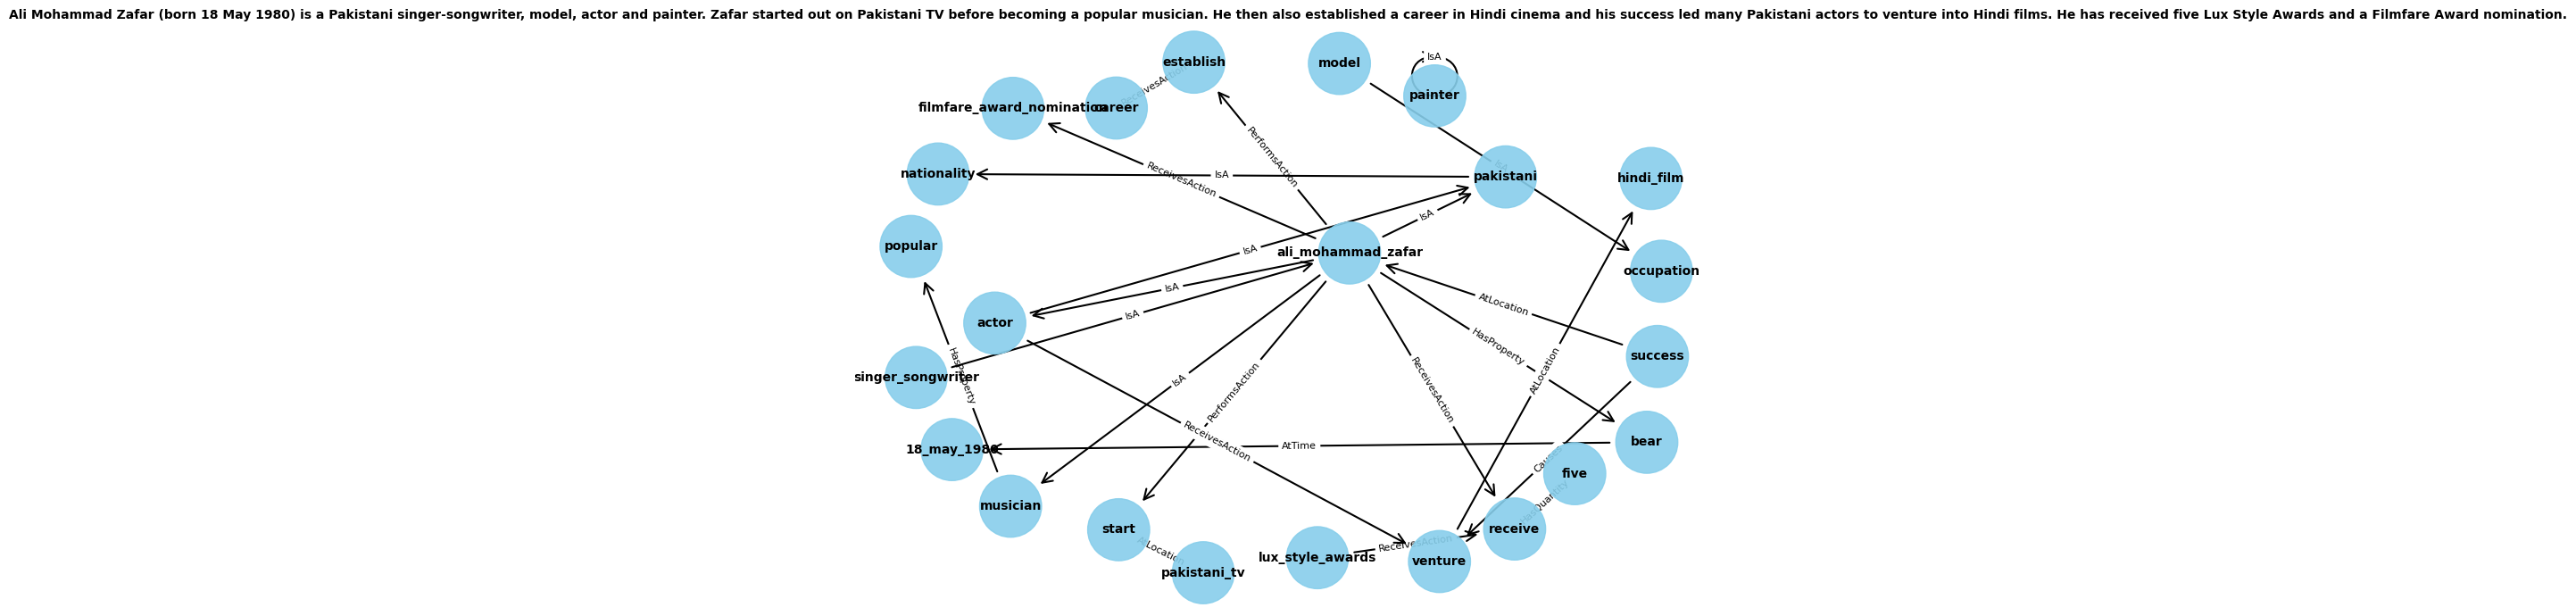

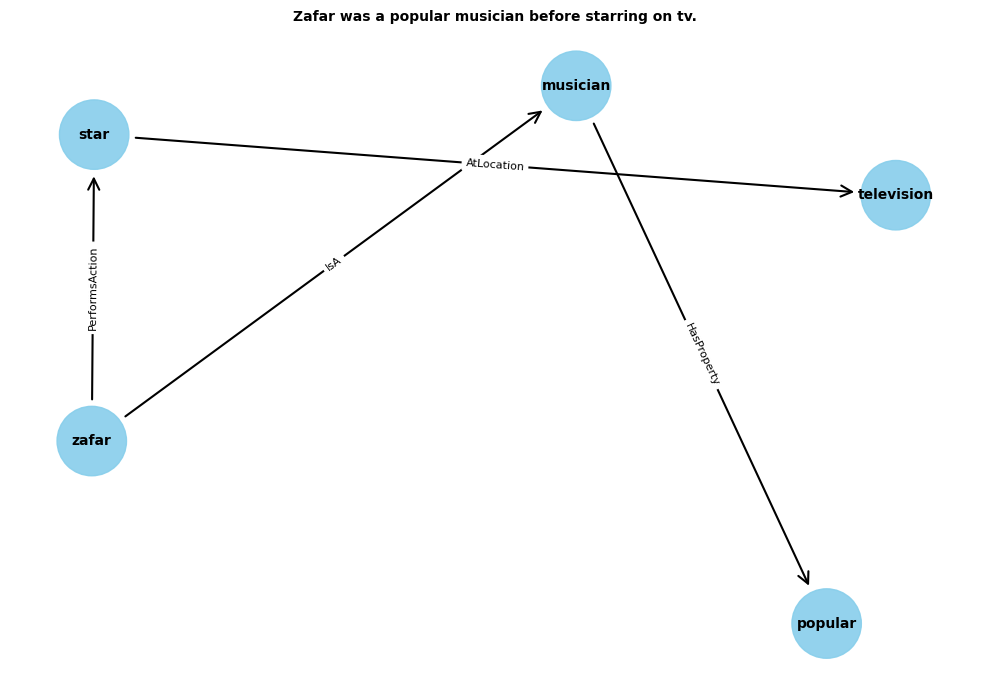

label : contradiction


In [78]:
P.display()
H.display()
print("label :", LABELS[row["label"]])

In [ ]:
P_paths = related_data(P, H, threshold_link= 0.3, threshold_path= 0.5, dist = 2)
P_paths[0]


,id_path,head,rel,tail,score_link,info_scored
0,0,actor,AtLocation,television,1.000000,television
1,1,actor,AtLocation,show,0.630406,star is located at television
2,1,show,AtLocation,television,1.000000,television
3,2,actor,AtLocation,show,0.630406,star is located at television
4,2,show,AtLocation,theatre,0.352058,star is located at television
5,3,actor,AtLocation,show,0.630406,star is located at television
6,3,show,UsedFor,entertainment,0.349416,star is located at television
7,4,actor,AtLocation,show,0.630406,star is located at television
8,4,show,IsA,entertainment,0.349272,star is located at television
9,5,actor,AtLocation,show,0.630406,star is located at television


In [83]:
P_paths[1]

,id_path,score_path
0,0,1.000000
1,1,0.907602
2,2,0.560819
3,3,0.560159
4,4,0.560123
5,5,0.559548
6,6,0.540158
7,7,0.523327


In [ ]:
H_paths = related_data(H, P, threshold_link= 0.3, threshold_path=0.5,dist = 2, forward= False)
H_paths[0]


,id_path,head,rel,tail,score_link,info_scored
0,0,actor,AtLocation,television,1.000000,actor
1,1,television_show,AtLocation,television,0.545122,start is located at pakistani tv
2,1,television,IsA,tv,0.388144,start is located at pakistani tv
3,2,information,AtLocation,television,0.537664,start is located at pakistani tv
4,2,television,IsA,tv,0.388144,start is located at pakistani tv


In [88]:
H_paths[1]

,id_path,score_path
0,0,1.000000
1,1,0.505877
2,2,0.500284


In [ ]:
score_path([0.9,0.9])

In [ ]:
score_path([0.2,1])


In [1]:
import spacy

nlp = spacy.load("en_core_web_sm")

def lemmatize_entity(text):
    doc = nlp(text)
    keep = [
        t for t in doc
        if t.pos_ not in {"DET", "ADP", "CCONJ", "SCONJ", "PUNCT", "PART", "AUX"}
        or t.lemma_.lower() in {"not", "no", "never"}
    ]
    if not keep:
        keep = list(doc)
    lemmas = [t.lemma_.lower() for t in keep]
    return "_".join(lemmas)

In [2]:
lemmatize_entity("born")

'bear'

In [ ]:
lemmatize_entity("upward")
